# Como rodar este projeto

Siga este fluxo no terminal:

1. Crie o ambiente Conda com Python 3.10:
   ```bash
   conda create -n trillia python=3.10 -y
   conda activate trillia
   ```

2. Entre na pasta do projeto:
   ```bash
   cd /seu-caminho-até-a-pasta/processos_seletivos/challenge-data-scientist/monitoring
   ```

3. Instale as dependências do projeto:
   ```bash
   make install
   ```

4. Inicie o servidor FastAPI em uma janela de terminal e deixe aberto:
   ```bash
   make run-server
   ```
   Isso sobe a API em http://127.0.0.1:8001

5. Abra uma segunda janela de terminal, no mesmo diretório, e rode o notebook:
   ```bash
   make run-notebook
   ```

6. Os comandos Make disponíveis são:
   ```bash
   make help
   make install
   make run-server
   make run-notebook
   ```

> Importante: o servidor precisa ficar rodando em uma janela enquanto o notebook é executado na outra.

Abaixo, o notebook mostra as chamadas aos endpoints da API.

# Trillia[B3] – Desafio Técnico

Prazo de entrega: 18/08 às 12h.

## 0.5 Configuração Inicial e Imports

In [47]:
# Célula 1
from pathlib import Path
import json
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Defina a URL base da sua API rodando localmente
API_BASE_URL = "http://127.0.0.1:8001"

## 1. Chamadas dos endpoints

Esta seção reproduz os dois fluxos exigidos no README: a avaliação de performance e a avaliação de aderência.

### 1.1 Endpoint de performance

Este endpoint responde a duas perguntas do monitoramento do modelo:
1. Qual foi a volumetria por mês do lote recebido?
2. Qual foi a performance do modelo nesse batch, medida pela AUC-ROC?

O README pede que o notebook mostre explicitamente a etapa de preparação dos dados antes do envio para a API:
- carregar o JSON em um DataFrame;
- substituir valores nulos por `np.nan`;
- enviar a lista de registros como payload para o endpoint.

A célula abaixo faz exatamente esse fluxo para seguir o que foi solicitado no README.

-> Localizando e preparando os dados do lote...
-> Enviando dados para a API de Performance...

 RESULTADOS DA AVALIAÇÃO DE PERFORMANCE

(a) Volumetria (Quantidade de registros por mês):
    - 2017-01: 58 registros
    - 2017-02: 55 registros
    - 2017-03: 62 registros
    - 2017-04: 49 registros
    - 2017-05: 67 registros
    - 2017-06: 63 registros
    - 2017-07: 74 registros
    - 2017-08: 72 registros

(b) Performance do Modelo (AUC-ROC):
    - AUC-ROC Global: 0.5752

-> Gerando visualização gráfica da volumetria e curva ROC...


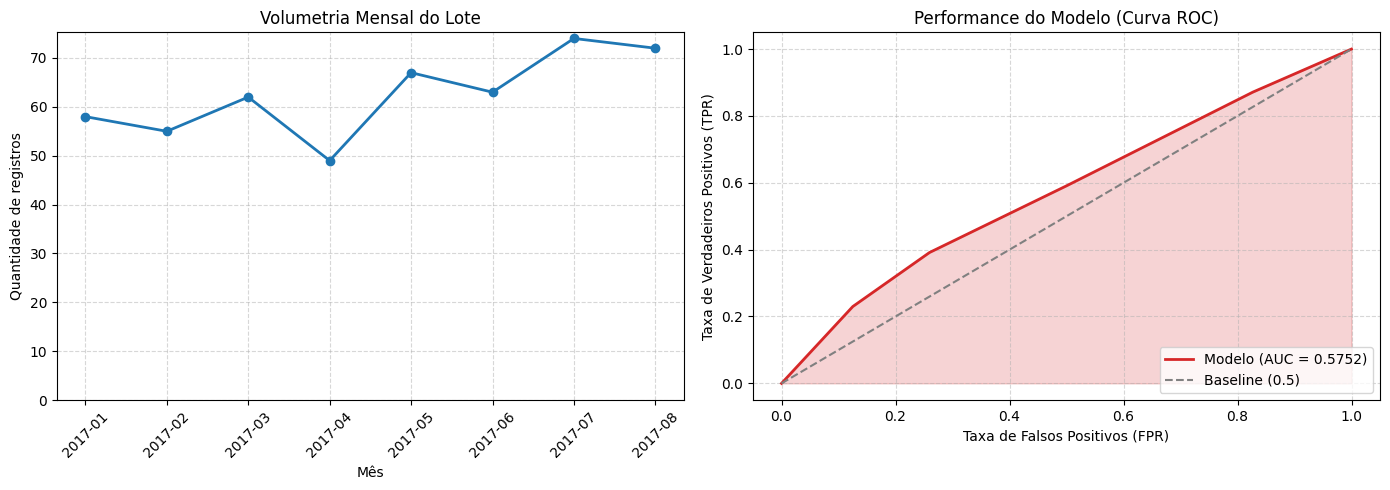

In [48]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt

# =====================================================================
# SEÇÃO 1: CARREGAMENTO E PREPARAÇÃO DOS DADOS
# =====================================================================
print("-> Localizando e preparando os dados do lote...")

base_dir = Path.cwd()
json_path = base_dir / "batch_records.json"
if not json_path.exists():
    json_path = base_dir / "monitoring" / "batch_records.json"

with json_path.open("r", encoding="utf-8") as file:
    records = json.load(file)

frame = pd.DataFrame.from_records(records)
frame = frame.replace([np.inf, -np.inf], np.nan)
frame = frame.replace({None: np.nan})
frame = frame.where(pd.notna(frame), None)

def _clean_for_json(value):
    if isinstance(value, dict):
        return {key: _clean_for_json(item) for key, item in value.items()}
    if isinstance(value, list):
        return [_clean_for_json(item) for item in value]
    if isinstance(value, float):
        return None if not np.isfinite(value) else value
    return value

payload = _clean_for_json(frame.to_dict(orient="records"))

# =====================================================================
# SEÇÃO 2: CHAMADA À API DE PERFORMANCE
# =====================================================================
print("-> Enviando dados para a API de Performance...")

API_URL = "http://127.0.0.1:8001/v1/performance/"
response = requests.post(API_URL, json=payload, timeout=120)
response.raise_for_status()
result = response.json()

# =====================================================================
# SEÇÃO 3: EXIBIÇÃO DOS RESULTADOS OBRIGATÓRIOS (DESAFIO)
# =====================================================================
print("\n" + "="*50)
print(" RESULTADOS DA AVALIAÇÃO DE PERFORMANCE")
print("="*50)

# (a) Volumetria mensal
print("\n(a) Volumetria (Quantidade de registros por mês):")
volumetria = result["volumetria"]
for mes, qtd in volumetria.items():
    print(f"    - {mes}: {qtd} registros")

# (b) Performance do modelo
auc_roc = result["auc_roc"]
print(f"\n(b) Performance do Modelo (AUC-ROC):")
print(f"    - AUC-ROC Global: {auc_roc:.4f}")
print("="*50 + "\n")

# =====================================================================
# SEÇÃO 4: VISUALIZAÇÃO GRÁFICA (BÔNUS)
# =====================================================================
print("-> Gerando visualização gráfica da volumetria e curva ROC...")

# Extraindo as coordenadas para o gráfico
meses = list(volumetria.keys())
quantidades = list(volumetria.values())
fpr = result["fpr"]
tpr = result["tpr"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Volumetria por mês
axes[0].plot(meses, quantidades, marker="o", color="tab:blue", linewidth=2)
axes[0].set_title("Volumetria Mensal do Lote")
axes[0].set_xlabel("Mês")
axes[0].set_ylabel("Quantidade de registros")
axes[0].set_ylim(bottom=0) 
axes[0].grid(True, linestyle="--", alpha=0.5)
axes[0].tick_params(axis='x', rotation=45)

# Gráfico 2: Curva ROC
axes[1].plot(fpr, tpr, color="tab:red", linewidth=2, label=f"Modelo (AUC = {auc_roc:.4f})")
axes[1].plot([0, 1], [0, 1], color="gray", linestyle="--", label="Baseline (0.5)")
axes[1].fill_between(fpr, tpr, alpha=0.2, color="tab:red")

axes[1].set_title("Performance do Modelo (Curva ROC)")
axes[1].set_xlabel("Taxa de Falsos Positivos (FPR)")
axes[1].set_ylabel("Taxa de Verdadeiros Positivos (TPR)")
axes[1].legend(loc="lower right")
axes[1].grid(True, linestyle="--", alpha=0.5)

fig.tight_layout()
plt.show()

### 1.2 Endpoint de aderência

Este endpoint responde a pergunta: a distribuição de scores desta base está compatível com a distribuição da base de teste do modelo?

Para isso, ele:
- lê o dataset local informado pelo usuário;
- usa o modelo pré-treinado para gerar scores;
- compara esses scores com os scores da base de teste;
- calcula a estatística KS e o valor-p do teste.

A célula abaixo mostra o fluxo de chamada do endpoint de aderência, conforme o README exige.


 AVALIANDO BASE: train.gz

--- Métricas de Aderência ---
Estatística KS : 0.0019
Valor-p        : 9.9932e-01
Média (Teste)  : 0.7924
Média (Atual)  : 0.7925
Volumetria     : 120750 registros

--- Categorias desconhecidas (substituídas por NaN antes de escorar) ---
Base avaliada (train.gz): 0 substituições
Base de teste: 0 substituições



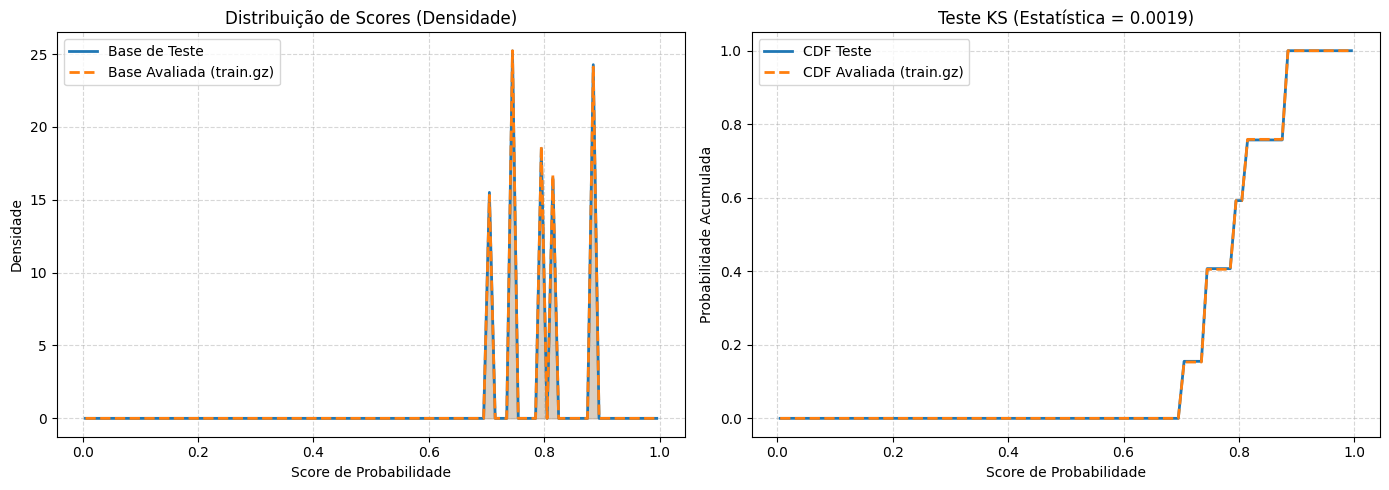


 AVALIANDO BASE: oot.gz

--- Métricas de Aderência ---
Estatística KS : 0.0912
Valor-p        : 7.0185e-240
Média (Teste)  : 0.7924
Média (Atual)  : 0.8001
Volumetria     : 91965 registros

--- Categorias desconhecidas (substituídas por NaN antes de escorar) ---
Base avaliada (oot.gz): 88346 substituições
    - VAR102: 1120
    - VAR103: 3377
    - VAR104: 1785
    - VAR105: 2513
    - VAR106: 980
    - VAR107: 183
    - VAR108: 1720
    - VAR109: 1508
    - VAR110: 593
    - VAR111: 1404
    - VAR112: 749
    - VAR113: 70
    - VAR114: 274
    - VAR115: 1247
    - VAR116: 10629
    - VAR117: 2074
    - VAR118: 11962
    - VAR119: 13
    - VAR121: 3
    - VAR122: 469
    - VAR123: 2028
    - VAR124: 3349
    - VAR125: 1731
    - VAR126: 634
    - VAR127: 85
    - VAR128: 4586
    - VAR129: 375
    - VAR130: 68
    - VAR131: 1749
    - VAR132: 4104
    - VAR133: 2124
    - VAR134: 772
    - VAR135: 4256
    - VAR136: 94
    - VAR137: 854
    - VAR138: 337
    - VAR139: 552
    - VAR140

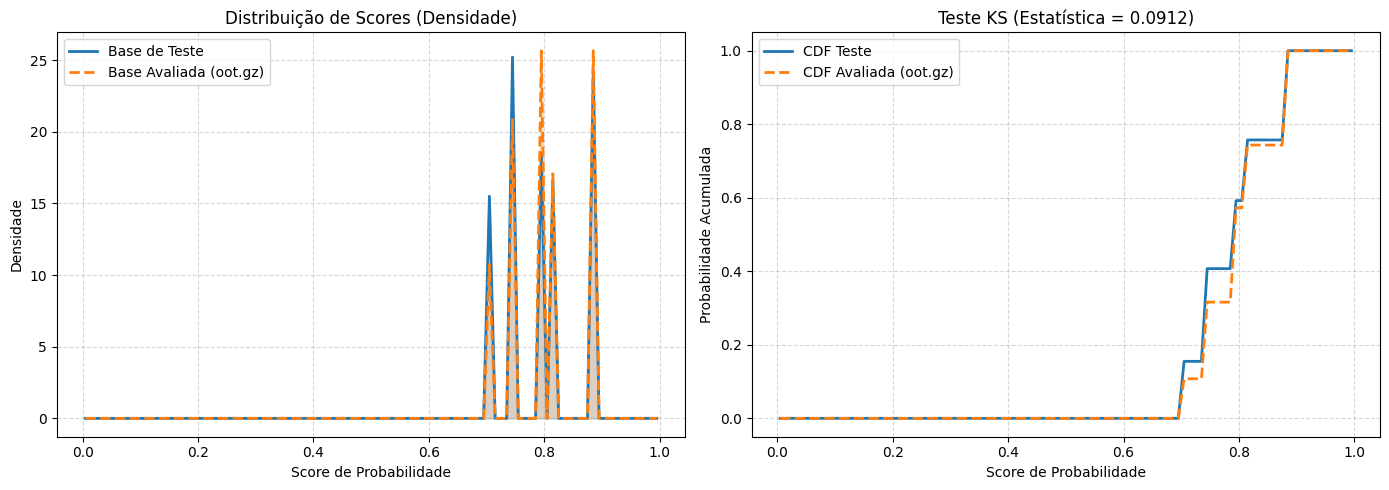

In [51]:
from pathlib import Path
import requests
import matplotlib.pyplot as plt

def avaliar_aderencia(nome_arquivo):
    print(f"\n{'='*50}")
    print(f" AVALIANDO BASE: {nome_arquivo}")
    print(f"{'='*50}")
    
    # 1) Localizar a base
    base_dir = Path.cwd()
    dataset_path = base_dir / "datasets" / "credit_01" / nome_arquivo
    if not dataset_path.exists():
        dataset_path = base_dir.parent / "datasets" / "credit_01" / nome_arquivo

    dataset_path_str = dataset_path.resolve().as_posix()

    # 2) Chamar o endpoint de aderência
    api_url = "http://127.0.0.1:8001/v1/aderencia/"
    try:
        response = requests.post(
            api_url,
            json={"dataset_path": dataset_path_str},
            timeout=120,
        )
        response.raise_for_status()
    except requests.exceptions.HTTPError as e:
        print(f"Erro na API ao processar a base {nome_arquivo}:")
        print(response.text) # Imprime o detalhe do erro 500 se ocorrer
        return

    # 3) Processar o retorno
    result = response.json()

    # Exibe as métricas de resumo
    print("\n--- Métricas de Aderência ---")
    print(f"Estatística KS : {result['ks_statistic']:.4f}")
    print(f"Valor-p        : {result['p_value']:.4e}")
    print(f"Média (Teste)  : {result['score_media_teste']:.4f}")
    print(f"Média (Atual)  : {result['score_media_input']:.4f}")
    print(f"Volumetria     : {result['n_registros_input']} registros\n")

    # Exibe quantos valores foram substituídos por NaN por conterem categorias
    # desconhecidas do treino (audita se o KS pode estar sendo mascarado pela sanitização)
    print("--- Categorias desconhecidas (substituídas por NaN antes de escorar) ---")
    total_input = result.get("total_substituicoes_input", 0)
    total_teste = result.get("total_substituicoes_teste", 0)
    print(f"Base avaliada ({nome_arquivo}): {total_input} substituições")
    if result.get("categorias_desconhecidas_input"):
        for coluna, qtd in result["categorias_desconhecidas_input"].items():
            print(f"    - {coluna}: {qtd}")
    print(f"Base de teste: {total_teste} substituições")
    if result.get("categorias_desconhecidas_teste"):
        for coluna, qtd in result["categorias_desconhecidas_teste"].items():
            print(f"    - {coluna}: {qtd}")
    print()

    # 4) Plotar os gráficos
    bins = result["score_bins"]
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Gráfico 1: Densidade
    axes[0].plot(bins, result["density_teste"], label="Base de Teste", color="tab:blue", linewidth=2)
    axes[0].plot(bins, result["density_input"], label=f"Base Avaliada ({nome_arquivo})", linestyle="--", color="tab:orange", linewidth=2)
    axes[0].fill_between(bins, result["density_teste"], alpha=0.2, color="tab:blue")
    axes[0].fill_between(bins, result["density_input"], alpha=0.2, color="tab:orange")
    axes[0].set_title("Distribuição de Scores (Densidade)")
    axes[0].set_xlabel("Score de Probabilidade")
    axes[0].set_ylabel("Densidade")
    axes[0].legend()
    axes[0].grid(True, linestyle="--", alpha=0.5)

    # Gráfico 2: CDF e KS
    axes[1].plot(bins, result["cdf_teste"], label="CDF Teste", color="tab:blue", linewidth=2)
    axes[1].plot(bins, result["cdf_input"], label=f"CDF Avaliada ({nome_arquivo})", linestyle="--", color="tab:orange", linewidth=2)
    axes[1].set_title(f"Teste KS (Estatística = {result['ks_statistic']:.4f})")
    axes[1].set_xlabel("Score de Probabilidade")
    axes[1].set_ylabel("Probabilidade Acumulada")
    axes[1].legend()
    axes[1].grid(True, linestyle="--", alpha=0.5)

    fig.tight_layout()
    plt.show()

# ---------------------------------------------------------
# EXECUTANDO OS TESTES PEDIDOS NO DESAFIO TÉCNICO
# ---------------------------------------------------------

# (a) Teste com a base de Treino
avaliar_aderencia("train.gz")

# (b) Teste com a base Out-of-Time
avaliar_aderencia("oot.gz")

Nota sobre a confiabilidade do KS no oot.gz

O teste de aderência no oot.gz retornou KS = 0.0912, abaixo do limiar geralmente usado em monitoramento de crédito para disparar alerta (~0.20) ou mesmo para deriva moderada (~0.10). Isso poderia sugerir que a distribuição de scores segue estável entre a base de Teste e o período OOT.

No entanto, esse número deve ser lido com ressalva. A API precisa neutralizar categorias não vistas no treino antes de escorar (substituindo-as por NaN), pois o modelo quebra ao encontrá-las — e no oot.gz isso afeta 88.346 valores em 91.965 registros (quase 1 substituição por linha), concentrados num bloco de ~37 variáveis de distância (VAR102 a VAR140), com destaque para VAR140 (~20% das linhas), VAR118 (~13%) e VAR116 (~12%). Na base de Teste, por comparação, nenhuma substituição é necessária.

Como essa fração de dados chega ao modelo com informação faltante, o NaN tende a ser tratado de forma mais "neutra" pelo pipeline, o que pode comprimir a distribuição de score resultante e subestimar o KS real — ou seja, o valor observado é mais um piso otimista da deriva do que uma medida limpa dela. O padrão concentrado num bloco específico de variáveis (aparentemente derivadas de distância/geolocalização) sugere uma mudança na forma como essas features são geradas ou bucketizadas nos meses mais recentes, o que por si só já é um sinal de monitoramento a ser investigado — independentemente do valor final do KS.